# <center>Lecture 3: Logistic regression and the GLM connection</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 3, sections 3.1–3.4** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering parametric random utility models (3.1), multinomial logistic regression (3.2), computation with gradient descent (3.3) and logistic regression as a generalized linear model (3.4). It runs the book's code listings `3-01`, `3-02` and `3-09`. Sections 3.5–3.8 — identification, the zero-cell problem, regularization and minimax regret — are lecture 4. Slide deck: folders `ch3/ch3.1`–`ch3/ch3.4`.

### Learning objectives

* The parametric random utility model $U_{iy}(\lambda) = (\Phi\lambda)_{iy}$, and the two estimators it suggests: maximum likelihood and the method of moments.
* Why they coincide in the logit case and only there, and why the method of moments is the computationally attractive one in general.
* The dual problem: **minimize the entropy of choice subject to moment matching**, with $\lambda$ as the Lagrange multipliers.
* Gradient and Hessian of the log-likelihood in matrix form; gradient descent, and why the natural step size is $1/L$.
* The Poisson trick: multinomial logistic regression *is* a Poisson regression with individual fixed effects, and the fixed effect is the indirect utility.
* Inference: the Fisher information matrix, and why the standard errors a Poisson routine reports are wrong here.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 3, sections 3.1–3.4**.
* McFadden (1974). "Conditional Logit Analysis of Qualitative Choice Behavior", in Zarembka (ed.), *Frontiers in Econometrics*. The conditional logit model estimated here.
* Gouriéroux, Monfort and Trognon (1984). "Pseudo Maximum Likelihood Methods: Theory". *Econometrica*. The method-of-moments view.
* McCullagh and Nelder (1989). *Generalized Linear Models*. 2nd ed. Chapman and Hall.
* Guimarães, Figueirdo and Woodward (2003); Baker (1994); Palmgren (1981). The Poisson–multinomial equivalence, known in machine learning as the "Poisson trick".
* Jaynes (1957). "Information Theory and Statistical Mechanics". *Physical Review*. The maximum-entropy principle that theorem 3.1 generalizes.
* Greene and Hensher (1997); Greene (2000), *Econometric Analysis*. The travel-mode data and the specification of example 3.1.
* Previous lectures: `dc01_random-utility-welfare-and-inversion` ($G$, $\pi$, $G^\ast$); `dc02_logit-mev-and-max-stability` (the Gumbel and its closed forms).

## Motivation: from shares to parameters

Lecture 1 inverted market shares into systematic utilities, one utility per option — four numbers for four travel modes, and no way to say anything about a mode that does not yet exist, or about how a traveller with a different income would choose. Lecture 2 pinned down the distribution of heterogeneity but left $U$ unrestricted.

This lecture puts structure on $U$:
$$U_{iy}(\lambda) = \sum_{k\in[K]}\phi_{iyk}\lambda_k = (\Phi\lambda)_{iy},$$
where $\phi_{iyk}$ are observed characteristics of the individual–option pair. Now there are $K$ parameters rather than $Y$ utilities, the model extrapolates to new options and new individuals, and $\lambda$ has economic content — a marginal utility of time, of money, an income interaction.

Two estimators present themselves. **Maximum likelihood** maximizes $\sum_{iy}\hat\pi_{iy}\log\pi_{iy}^\lambda$. The **method of moments** matches predicted to observed moments, $\Phi^\top\pi^\lambda = \Phi^\top\hat\pi$. The second turns out to be the first-order condition of a *convex* problem for any $\mathcal{P}$, while the likelihood need not even be concave; and in the logit case — and, as the book stresses, in that case only — the two coincide.

**The dual object.** Theorem 3.1 below is the pivot of the whole chapter. The estimation problem
$$\max_\lambda\Big\{\hat\pi^\top\Phi\lambda - \sum_i G\big((\Phi\lambda)_{i\cdot}\big)\Big\}$$
is dual to
$$\min_{\pi\ge0}\ \sum_i G^\ast(\pi_{i\cdot})\quad\text{s.t.}\quad \Phi^\top\pi = \Phi^\top\hat\pi,$$
**and $\lambda$ is the vector of Lagrange multipliers on the moment-matching constraints.** So estimation is a maximum-entropy problem: among all choice distributions reproducing the observed moments, pick the one requiring the least heterogeneity. The parameters are the shadow prices of the moments. That is the same $G/G^\ast$ conjugate pair as lecture 1, now carrying a constraint — and section 5 will add a second multiplier, $u_i$, on the constraint that each individual makes one choice, which turns out to be their indirect utility.

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.optimize import minimize
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)          # lecture number
FAST_MODE = True

np.set_printoptions(precision=4, suppress=True)

## 1. The parametric model, and our data

*(Book, section 3.1. Runs listing `3-09`.)*

Individual $i\in[I]$ chooses among $y\in[Y]$; there is no distinguished default option in this chapter. Utility is $U_{iy}+\varepsilon_{iy}$ with $\varepsilon_i\sim\mathcal{P}$ satisfying the continuity assumption, and
$$U_{iy}(\lambda) = (\Phi\lambda)_{iy},\qquad \Phi \text{ of size } (IY)\times K.$$

Writing $\pi^\lambda_{iy} = \pi_y\big((\Phi\lambda)_{i\cdot}\big) = \partial G/\partial U_y$ for the predicted choice probability and $\hat\pi_{iy} = \mathbf{1}\{y_i=y\}$ for the observed choice dummy:

> **Definition (book 3.1).** The **maximum likelihood** estimator solves $\max_\lambda \sum_{iy}\hat\pi_{iy}\log\pi^\lambda_{iy}$.

> **Definition (book 3.2).** The **method of moments** estimator solves $\sum_{iy}\pi^\lambda_{iy}\phi_{iyk} = \sum_{iy}\hat\pi_{iy}\phi_{iyk}$ for every $k\in[K]$.

The book's example 3.1 is the Greene–Hensher travel-mode data with $K=3$: in-vehicle travel time, travel time interacted with income, and generalized cost. Listing `3-09` builds it, standardizing the columns of $\Phi$ so that the three coefficients are comparable in magnitude.

In [2]:
from pathlib import Path


def read_mec_csv(relative_path):
    """Load a dataset locally when available, otherwise use the public mirror."""
    for parent in (Path.cwd(), *Path.cwd().parents):
        local = parent / 'mec_datasets' / relative_path
        if local.is_file():
            return pd.read_csv(local)
    url = ('https://raw.githubusercontent.com/math-econ-code/'
           'mec_datasets/main/' + relative_path)
    try:
        return pd.read_csv(url)
    except Exception as exc:
        raise RuntimeError(
            f'could not load {relative_path}; no local mec_datasets copy was found '
            f'and the download failed: {url}'
        ) from exc


def load_travel_data():
    '''Listing 3-09: the Greene-Hensher travel-mode data in the book's specification.

    Returns I, Y, K, pihat_iy (choice dummies) and Phi_iy_k (standardized
    regressors: travel time; minus travel time x income; minus generalized cost).
    '''
    the_data = read_mec_csv('demand_travelmode/travelmodedata.csv')
    pihat_iy = np.where(the_data['choice'] == 'yes', 1, 0).astype(float)
    Y = the_data['mode'].nunique()
    I = the_data.shape[0] // Y
    cov = the_data[['travel', 'income', 'gcost']].values
    Phi_iy_k = np.column_stack([cov[:, 0], -(cov[:, 0] * cov[:, 1]), -cov[:, 2]])
    Phi_iy_k = ((Phi_iy_k - Phi_iy_k.mean(axis=0)) / Phi_iy_k.std(axis=0, ddof=1))
    return I, Y, Phi_iy_k.shape[1], pihat_iy, Phi_iy_k


I, Y, K, pihat_iy, Phi_iy_k = load_travel_data()
modes = ['air', 'train', 'bus', 'car']          # the order the csv is stored in
regressors = ['travel time', '-(travel time x income)', '-generalized cost']

print(f'I = {I}   Y = {Y}   K = {K}   Phi is {Phi_iy_k.shape}')
print('\nobserved shares :', dict(zip(modes, pihat_iy.reshape(I, Y).mean(axis=0).round(4))))
print('\nregressor means (standardized) :', Phi_iy_k.mean(axis=0).round(12))
print('regressor s.d.  (standardized) :', Phi_iy_k.std(axis=0, ddof=1).round(12))

I = 210   Y = 4   K = 3   Phi is (840, 3)

observed shares : {'air': np.float64(0.2762), 'train': np.float64(0.3), 'bus': np.float64(0.1429), 'car': np.float64(0.281)}

regressor means (standardized) : [ 0. -0.  0.]
regressor s.d.  (standardized) : [1. 1. 1.]


Note the sign convention baked into listing `3-09`: the second and third regressors enter with a minus sign, so that a *positive* $\lambda_k$ means the corresponding cost hurts. The first enters positive, so its coefficient will be read as the utility of travel time — expected to be negative.

The standardization matters for the gradient descent of section 3: it makes the Hessian better conditioned, and hence the fixed step size usable. It changes the units of $\lambda$ but nothing about the fit.

## 2. Two estimators, and the maximum-entropy dual

*(Book, section 3.1, theorem 3.1.)*

Since $\pi^\lambda_{iy} = \partial G/\partial U_y$, the quantity $\sum_y\pi^\lambda_{iy}\phi_{iyk}$ is the derivative of $G\big((\Phi\lambda)_{i\cdot}\big)$ with respect to $\lambda_k$. So the moment conditions are the first-order conditions of a **convex** problem, and there is a dual:

> **Theorem (book 3.1).** Under the continuity assumption,
> $$\hat\lambda_{MM} \in \arg\max_{\lambda\in\mathbb{R}^K}\Big\{\hat\pi^\top\Phi\lambda - \sum_{i\in[I]}G\big((\Phi\lambda)_{i\cdot}\big)\Big\},$$
> whose value equals that of the dual
> $$\min_{\pi\ge0}\ \sum_{i\in[I]}G^\ast(\pi_{i\cdot})\quad\text{s.t.}\quad \big((\pi-\hat\pi)^\top\Phi\big)_k = 0\ \ [\lambda_k],$$
> and $\hat\lambda_{MM}$ is the vector of multipliers on those constraints.

**Minimize the heterogeneity needed, subject to reproducing the observed moments.** This is Jaynes's maximum-entropy principle, generalized from the Gibbs entropy to an arbitrary $G^\ast$, and it is the reason a discrete choice estimator is a convex program rather than a search.

In the logit case $G = \log\sum_y e^{U_y}$ and $G^\ast = \sum_y \pi\log\pi$, and the likelihood becomes
$$\ell(\lambda) = \hat\pi^\top\Phi\lambda - \sum_{i\in[I]}\log\Big(\sum_{y}e^{(\Phi\lambda)_{iy}}\Big),$$
which is *literally* the objective of the moment problem:

> **Proposition (book 3.2).** In the logit case, and only there, the maximum likelihood and method of moments estimators coincide.

In [3]:
def loglike(lambda_k, Phi_iy_k, pihat_iy, I, Y):
    '''Log-likelihood of the multinomial logistic regression, expression (3.9).'''
    Philambda_i_y = (Phi_iy_k @ lambda_k).reshape(I, Y)
    return float(pihat_iy @ (Phi_iy_k @ lambda_k)
                 - np.logaddexp.reduce(Philambda_i_y, axis=1).sum())


def shares(lambda_k, Phi_iy_k, I, Y):
    '''Predicted choice probabilities pi^lambda_iy, computed stably.'''
    Philambda_i_y = (Phi_iy_k @ lambda_k).reshape(I, Y)
    return np.exp(Philambda_i_y
                  - np.logaddexp.reduce(Philambda_i_y, axis=1)[:, None]).reshape(-1)


def grad_loglike(lambda_k, Phi_iy_k, pihat_iy, I, Y):
    '''Gradient: Phi^T (pihat - pi^lambda), expression (3.14).'''
    return (pihat_iy - shares(lambda_k, Phi_iy_k, I, Y)) @ Phi_iy_k


def hess_loglike(lambda_k, Phi_iy_k, I, Y):
    '''Hessian: -Phi^T (Delta_pi - Delta_pi (I_I kron 1_YxY) Delta_pi) Phi.'''
    pi_i_y = shares(lambda_k, Phi_iy_k, I, Y).reshape(I, Y)
    Phi_i_y_k = Phi_iy_k.reshape(I, Y, -1)
    A = np.einsum('iy,iyk,iyl->kl', pi_i_y, Phi_i_y_k, Phi_i_y_k)
    m_i_k = np.einsum('iy,iyk->ik', pi_i_y, Phi_i_y_k)          # per-individual mean
    B = np.einsum('ik,il->kl', m_i_k, m_i_k)
    return -(A - B)

In [4]:
# --- the analytic gradient and Hessian, against finite differences
lam_test = np.array([0.4, -0.3, 0.7])
h = 1e-6
g_fd = np.array([(loglike(lam_test + h * e, Phi_iy_k, pihat_iy, I, Y)
                  - loglike(lam_test - h * e, Phi_iy_k, pihat_iy, I, Y)) / (2 * h)
                 for e in np.eye(K)])
g_an = grad_loglike(lam_test, Phi_iy_k, pihat_iy, I, Y)

H_fd = np.array([[(grad_loglike(lam_test + h * e, Phi_iy_k, pihat_iy, I, Y)
                   - grad_loglike(lam_test - h * e, Phi_iy_k, pihat_iy, I, Y))[l]
                  / (2 * h) for l in range(K)] for e in np.eye(K)])
H_an = hess_loglike(lam_test, Phi_iy_k, I, Y)

print('gradient  analytic :', g_an)
print('gradient  finite d :', g_fd)
print(f'  max gap = {np.abs(g_an - g_fd).max():.2e}   (tolerance 1e-5)')
print('\nHessian   analytic :\n', H_an)
print(f'  max gap to finite differences = {np.abs(H_an - H_fd).max():.2e}   (tolerance 1e-5)')
print('  eigenvalues :', np.linalg.eigvalsh(H_an).round(4),
      ' -> negative definite, so the log-likelihood is strictly concave')
assert np.abs(g_an - g_fd).max() < 1e-5 and np.abs(H_an - H_fd).max() < 1e-5
assert (np.linalg.eigvalsh(H_an) < 0).all()

gradient  analytic : [-76.1583  64.6586  19.3304]
gradient  finite d : [-76.1583  64.6586  19.3304]
  max gap = 5.17e-08   (tolerance 1e-5)

Hessian   analytic :
 [[-73.5987  48.345   24.8048]
 [ 48.345  -42.3257 -19.2437]
 [ 24.8048 -19.2437 -39.952 ]]
  max gap to finite differences = 3.44e-08   (tolerance 1e-5)
  eigenvalues : [-120.9334  -27.8321   -7.1109]  -> negative definite, so the log-likelihood is strictly concave


The matrix formulas of expression (3.14) are correct to five decimals against finite differences, and the Hessian is negative definite: **in the logit case the log-likelihood is strictly concave**, so there is at most one maximum and any ascent method that converges, converges to it. That is not true for a general $\mathcal{P}$ — which is exactly why the book routes estimation through the moment problem, whose convexity does not depend on the logit.

## 3. Gradient descent

*(Book, section 3.3. Runs listing `3-01`.)*

Listing `3-01` climbs $\ell$ with a fixed step,
$$\lambda^{t+1} = \lambda^t + \alpha\,\Phi^\top(\hat\pi - \pi^{\lambda^t}),\qquad \alpha = 1/\|\Phi\Phi^\top\|,$$
stopping when the gradient is small. The step size is not arbitrary: for a concave function with $L$-Lipschitz gradient, $\alpha = 1/L$ is the largest step guaranteed to make progress at every iteration, and $\|\Phi\Phi^\top\|$ is an upper bound on $L$ here — a conservative one, since it ignores the fact that $\mathbf\Delta_\pi$ has entries below one.

We run it, and compare against Newton's method, which uses the Hessian we just verified.

In [5]:
def gradient_ascent(Phi_iy_k, pihat_iy, I, Y, tol=1e-8, maxit=200_000):
    '''Listing 3-01: multinomial logistic regression by gradient ascent, fixed step.'''
    K_ = Phi_iy_k.shape[1]
    alpha = 1 / np.linalg.norm(Phi_iy_k @ Phi_iy_k.T)
    lambda_k = np.zeros(K_)
    path = [lambda_k.copy()]
    for t in range(maxit):
        grad_k = grad_loglike(lambda_k, Phi_iy_k, pihat_iy, I, Y)
        if np.linalg.norm(grad_k) < tol:
            break
        lambda_k = lambda_k + alpha * grad_k
        path.append(lambda_k.copy())
    return lambda_k, t, alpha, np.array(path)


def newton(Phi_iy_k, pihat_iy, I, Y, tol=1e-10, maxit=100):
    '''The same problem by Newton-Raphson, using the analytic Hessian.'''
    lambda_k = np.zeros(Phi_iy_k.shape[1])
    path = [lambda_k.copy()]
    for t in range(maxit):
        g = grad_loglike(lambda_k, Phi_iy_k, pihat_iy, I, Y)
        if np.linalg.norm(g) < tol:
            break
        lambda_k = lambda_k - np.linalg.solve(hess_loglike(lambda_k, Phi_iy_k, I, Y), g)
        path.append(lambda_k.copy())
    return lambda_k, t, np.array(path)


lam_gd, nit_gd, alpha_gd, path_gd = gradient_ascent(Phi_iy_k, pihat_iy, I, Y)
lam_nr, nit_nr, path_nr = newton(Phi_iy_k, pihat_iy, I, Y)

print(f'gradient ascent : {nit_gd:>6} iterations, step alpha = {alpha_gd:.3e}')
print(f'                  lambda = {lam_gd}')
print(f'Newton          : {nit_nr:>6} iterations')
print(f'                  lambda = {lam_nr}')
print(f'\nagreement between the two methods : {np.abs(lam_gd - lam_nr).max():.2e}'
      f'   (tolerance 1e-6)')
print(f'gradient norm at the optimum      : '
      f'{np.linalg.norm(grad_loglike(lam_nr, Phi_iy_k, pihat_iy, I, Y)):.2e}')
assert np.abs(lam_gd - lam_nr).max() < 1e-6

gradient ascent :   3391 iterations, step alpha = 5.031e-04
                  lambda = [0.1862 0.469  0.5506]
Newton          :      4 iterations
                  lambda = [0.1862 0.469  0.5506]

agreement between the two methods : 6.74e-10   (tolerance 1e-6)
gradient norm at the optimum      : 1.82e-14


Two algorithms, one answer. The gradient method needs thousands of iterations where Newton needs a handful — the price of a fixed step calibrated to a global Lipschitz bound. Newton is affordable here because $K=3$; when $K$ is large, or when the Hessian is not available, the fixed-step method is what remains, and lecture 4 will need its proximal variant for a nonsmooth penalty.

**Verification: the moment conditions.** The estimator was defined by matching moments. Whether the optimizer actually achieved that is a separate question from whether it stopped.

In [6]:
pi_hat_fitted = shares(lam_nr, Phi_iy_k, I, Y)
mom_pred = Phi_iy_k.T @ pi_hat_fitted
mom_obs = Phi_iy_k.T @ pihat_iy

print(f"{'regressor':>26} {'predicted moment':>18} {'observed moment':>17} {'gap':>12}")
for k in range(K):
    print(f'{regressors[k]:>26} {mom_pred[k]:>18.8f} {mom_obs[k]:>17.8f} '
          f'{abs(mom_pred[k]-mom_obs[k]):>12.2e}')
print(f'\nrow sums of pi^lambda all equal one : '
      f'{np.abs(pi_hat_fitted.reshape(I, Y).sum(axis=1) - 1).max():.2e}')

# predicted versus observed market shares (not imposed: only K = 3 moments were matched)
print('\nobserved market shares  :', pihat_iy.reshape(I, Y).mean(axis=0).round(4))
print('predicted market shares :', pi_hat_fitted.reshape(I, Y).mean(axis=0).round(4))
assert np.abs(mom_pred - mom_obs).max() < 1e-8

                 regressor   predicted moment   observed moment          gap
               travel time       -38.53763408      -38.53763408     2.84e-14
   -(travel time x income)        37.57306269       37.57306269     4.97e-14
         -generalized cost        30.88371959       30.88371959     3.55e-15

row sums of pi^lambda all equal one : 4.44e-16

observed market shares  : [0.2762 0.3    0.1429 0.281 ]
predicted market shares : [0.3188 0.1889 0.2144 0.278 ]


The three moments are matched to fourteen decimals — that is the estimator's *definition*, satisfied. The aggregate market shares, by contrast, are not matched and were never asked to be: only $K=3$ linear combinations of $\hat\pi$ were constrained, and the shares are four more numbers.

**And they miss, substantially.** Train is under-predicted at $0.189$ against an observed $0.300$; bus is over-predicted at $0.214$ against $0.143$. That is not a numerical failure, it is a specification diagnostic, and it has a clean cause: the book's example 3.1 contains no **alternative-specific constants**. Every difference between modes has to be explained through travel time and cost, so anything that makes a train intrinsically more attractive than a bus at equal time and cost — comfort, reliability, the walk to the station — has nowhere to go. Adding four mode dummies to $\Phi$ would match the shares *exactly*, because the share vector would then itself be among the matched moments. Exercise 4 asks you to do it.

This is the practical content of the dual in theorem 3.1: **the moments are the constraints, and everything else about the fit is a consequence, not a target.** If you want the model to reproduce a statistic, put that statistic in $\Phi$.

## 4. Logistic regression is a Poisson regression

*(Book, section 3.4. Runs listing `3-02`.)*

A Poisson regression of $\hat\pi$ on a design matrix $R$ solves
$$\max_{\theta}\Big\{\hat\pi^\top R\theta - \sum_{\omega}e^{(R\theta)_\omega}\Big\}.$$
Take the observations to be the pairs $\omega = iy$, and split the parameter as $\theta = (\lambda, u)$ with
$$R = \big(\ \Phi\ \ \ -\mathbf{I}_I\otimes\mathbf{1}_Y\ \big),$$
so that $(R\theta)_{iy} = (\Phi\lambda)_{iy} - u_i$: the regressors are the $\phi_{iyk}$ plus one dummy per individual. Maximizing over $u_i$ alone gives $1 = \sum_y e^{(\Phi\lambda)_{iy}-u_i}$, that is
$$u_i = \log\sum_{y}e^{(\Phi\lambda)_{iy}},$$
and substituting back recovers the multinomial logistic regression exactly.

> **Theorem (book 3.3).** The multinomial logistic regression can be estimated as a Poisson regression with an individual fixed effect.

**The fixed effect is the indirect utility.** $u_i = \log\sum_y e^{U_{iy}}$ is the expected indirect utility of individual $i$ in the logit model — the same $u_i$ that was the dual variable of lecture 1's inversion LP. And in the dual of the Poisson problem,
$$\min_{\pi\ge0}\sum_{iy}\pi_{iy}\log\pi_{iy}\quad\text{s.t.}\quad
\underbrace{\sum_y\pi_{iy}=1\ \ [u_i]}_{\text{one choice per individual}},\quad
\underbrace{\Phi^\top\pi = \Phi^\top\hat\pi\ \ [\lambda_k]}_{\text{moment matching}},$$
it is the multiplier on the constraint that each individual makes exactly one choice — a scarcity price. Two readings of the same number.

The book's listing uses scikit-learn's `PoissonRegressor`. We implement the Poisson objective directly, both to keep the notebook to numpy and scipy and because the equivalence is worth *computing* rather than delegating: if the two routes agree on $\hat\lambda$, theorem 3.3 has been verified rather than cited.

In [7]:
def poisson_regression(R, y_obs, tol=1e-12):
    '''Poisson regression: max_theta { y^T R theta - sum_omega exp(R theta)_omega }.

    Implemented directly rather than through a library, so that the equivalence with
    the multinomial logistic regression can be checked rather than assumed.
    '''
    R = sp.csr_matrix(R)

    def neg(theta):
        Rt = R @ theta
        return -(y_obs @ Rt - np.exp(Rt).sum())

    def neg_grad(theta):
        return -(R.T @ (y_obs - np.exp(R @ theta)))

    res = minimize(neg, np.zeros(R.shape[1]), jac=neg_grad, method='L-BFGS-B',
                   options={'gtol': tol, 'ftol': tol, 'maxiter': 100_000})
    return res.x, res


# listing 3-02's design matrix: regressors, then one dummy per individual
R_iy_p = sp.hstack([sp.csr_matrix(Phi_iy_k),
                    -sp.kron(sp.identity(I), np.ones((Y, 1)))]).tocsr()
theta, res = poisson_regression(R_iy_p, pihat_iy)
lam_glm, u_glm = theta[:K], theta[K:]

print('lambda, multinomial logistic (Newton) :', lam_nr)
print('lambda, Poisson regression with FE    :', lam_glm)
print(f'  max gap = {np.abs(lam_glm - lam_nr).max():.2e}   (tolerance 1e-5)')

u_direct = np.logaddexp.reduce((Phi_iy_k @ lam_nr).reshape(I, Y), axis=1)
print(f'\nfixed effects u_i versus log sum_y exp(Phi lambda)_iy :'
      f' max gap = {np.abs(u_glm - u_direct).max():.2e}')
print('first five u_i :', u_glm[:5])
print('   ... which are the expected indirect utilities of those five travellers.')
assert np.abs(lam_glm - lam_nr).max() < 1e-5

lambda, multinomial logistic (Newton) : [0.1862 0.469  0.5506]
lambda, Poisson regression with FE    : [0.1862 0.469  0.5506]
  max gap = 2.38e-06   (tolerance 1e-5)

fixed effects u_i versus log sum_y exp(Phi lambda)_iy : max gap = 1.11e-05
first five u_i : [2.0895 1.9868 0.949  1.8498 1.5364]
   ... which are the expected indirect utilities of those five travellers.


Theorem 3.3 verified: a Poisson regression over $213$ parameters and a three-parameter logistic regression return the same $\hat\lambda$ to within $3\times10^{-6}$, and the Poisson fixed effects reproduce $\log\sum_y e^{(\Phi\lambda)_{iy}}$ to about $10^{-5}$. (Those residual gaps are the L-BFGS tolerance on a 213-dimensional problem, not a discrepancy in the theorem; Newton on the 3-dimensional problem is exact to $10^{-14}$.) The 210 nuisance parameters are not noise to be tolerated — they are the travellers' indirect utilities, and they are the dual variables on "one choice per person".

### Verification: primal value equals dual value

Theorem 3.1 says the estimation problem and the constrained-entropy problem have the same value. Both are now computable.

In [8]:
primal_value = loglike(lam_nr, Phi_iy_k, pihat_iy, I, Y)
dual_value = float(np.sum(pi_hat_fitted * np.log(pi_hat_fitted)))     # sum_i G*(pi_i.)

print(f'primal  max_lambda {{ pihat^T Phi lambda - sum_i G }}  = {primal_value:.10f}')
print(f'dual    sum_i G*(pi_i.) at the fitted pi             = {dual_value:.10f}')
print(f'gap                                                  = '
      f'{abs(primal_value - dual_value):.2e}   (tolerance 1e-9)')
assert abs(primal_value - dual_value) < 1e-9

primal  max_lambda { pihat^T Phi lambda - sum_i G }  = -277.7052141446
dual    sum_i G*(pi_i.) at the fitted pi             = -277.7052141446
gap                                                  = 5.68e-14   (tolerance 1e-9)


In [9]:
# Is the fitted pi really the MINIMUM of the entropy over the feasible set?
# Move along random directions that preserve both sets of constraints and check.
Phi_i_y_k = Phi_iy_k.reshape(I, Y, K)
D = np.column_stack([np.kron(np.eye(I), np.ones(Y)).T,      # row-sum constraints
                     Phi_iy_k])                                  # moment constraints
# null space of the constraint matrix: feasible perturbation directions
_, s_vals, Vt = np.linalg.svd(D.T, full_matrices=True)
null_dirs = Vt[len(s_vals[s_vals > 1e-10]):]

ent = lambda p: float(np.sum(p * np.log(p)))
worse = 0
for j in range(min(200, null_dirs.shape[0])):
    d = null_dirs[j]
    for step in (1e-3, -1e-3, 1e-2, -1e-2):
        p = pi_hat_fitted + step * d
        if (p > 0).all() and ent(p) < dual_value - 1e-12:
            worse += 1

print(f'feasible perturbation directions tested : {min(200, null_dirs.shape[0])}')
print(f'directions that lowered the entropy     : {worse}')
print('\nthe fitted pi minimizes the entropy of choice subject to the constraints:')
print('it is a maximum-entropy distribution, and lambda prices the moments.')
assert worse == 0

feasible perturbation directions tested : 200
directions that lowered the entropy     : 0

the fitted pi minimizes the entropy of choice subject to the constraints:
it is a maximum-entropy distribution, and lambda prices the moments.


Not one feasible perturbation lowers the entropy. The fitted choice probabilities are the **least-heterogeneity distribution consistent with the observed moments**, and the estimated parameters are the shadow prices of those moments. Estimation and the maximum-entropy principle are the same computation, which is Jaynes's principle with $G^\ast$ in place of the Gibbs entropy.

### Inference, and a warning worth testing

The asymptotics come from the Fisher information matrix,
$$\hat B_{k\ell} = \frac1I\sum_{iy}\pi^\lambda_{iy}\phi_{iyk}\phi_{iy\ell} - \frac1I\sum_{iyz}\pi^\lambda_{iy}\pi^\lambda_{iz}\phi_{iyk}\phi_{iz\ell},$$
which is the average over individuals of the conditional variance of the regressor vector. Then

> **Theorem (book 3.4).** $\hat\lambda\to\lambda$ almost surely and $I^{1/2}(\hat\lambda-\lambda)\Rightarrow\mathcal{N}(0,B^{-1})$.

The book attaches a warning to the Poisson route: a GLM library treats the $IY$ rows as independent observations, which they are not, so **its standard errors are wrong even though its point estimates are right**. That is a checkable claim, so we check it — against $\hat B$ and against a Monte Carlo.

In [10]:
def fisher(lambda_k, Phi_iy_k, I, Y):
    '''Listing 3-02: the estimated Fisher information matrix Bhat.'''
    pi_i_y = shares(lambda_k, Phi_iy_k, I, Y).reshape(I, Y)
    Phi_i_y_k = Phi_iy_k.reshape(I, Y, -1)
    B1 = np.einsum('iy,iyk,iyl->kl', pi_i_y, Phi_i_y_k, Phi_i_y_k) / I
    m_i_k = np.einsum('iy,iyk->ik', pi_i_y, Phi_i_y_k)
    B2 = np.einsum('ik,il->kl', m_i_k, m_i_k) / I
    return B1 - B2


Bhat = fisher(lam_nr, Phi_iy_k, I, Y)
se_correct = np.sqrt(np.diag(np.linalg.inv(Bhat)) / I)

# the Hessian route must agree: -D^2 l = I * Bhat
print(f'-D^2 l / I  versus  Bhat : max gap = '
      f'{np.abs(-hess_loglike(lam_nr, Phi_iy_k, I, Y) / I - Bhat).max():.2e}')

# the "naive" standard errors a Poisson library reports: rows treated as independent
W = np.diag(np.exp(R_iy_p @ theta))
naive_info = (R_iy_p.T @ W @ R_iy_p)[:K, :K]
se_naive = np.sqrt(np.diag(np.linalg.inv(np.asarray(naive_info))))

print(f"\n{'':>26} {'estimate':>10} {'s.e. (Bhat)':>13} {'s.e. (naive Poisson)':>21}")
for k in range(K):
    print(f'{regressors[k]:>26} {lam_nr[k]:>10.4f} {se_correct[k]:>13.4f} '
          f'{se_naive[k]:>21.4f}')

-D^2 l / I  versus  Bhat : max gap = 5.55e-17

                             estimate   s.e. (Bhat)  s.e. (naive Poisson)
               travel time     0.1862        0.1889                0.1078
   -(travel time x income)     0.4690        0.2361                0.1077
         -generalized cost     0.5506        0.1820                0.0982


In [11]:
# Monte Carlo: which set of standard errors is right?
nrep = 4000 if not FAST_MODE else 2000
pi_true_i_y = pi_hat_fitted.reshape(I, Y)
cum = pi_true_i_y.cumsum(axis=1)
gen = np.random.default_rng(303)

lam_mc = np.empty((nrep, K))
for r in range(nrep):
    draws = (gen.random((I, 1)) > cum).sum(axis=1)             # one choice per person
    pihat_r = np.zeros((I, Y)); pihat_r[np.arange(I), draws] = 1.0
    lam_mc[r], _, _ = newton(Phi_iy_k, pihat_r.reshape(-1), I, Y)

se_mc = lam_mc.std(axis=0, ddof=1)
print(f"{'':>26} {'s.e. Monte Carlo':>18} {'s.e. (Bhat)':>13} {'s.e. (naive)':>14}")
for k in range(K):
    print(f'{regressors[k]:>26} {se_mc[k]:>18.4f} {se_correct[k]:>13.4f} '
          f'{se_naive[k]:>14.4f}')
print(f'\nBhat  / Monte Carlo ratio : {(se_correct / se_mc).round(3)}')
print(f'naive / Monte Carlo ratio : {(se_naive / se_mc).round(3)}')
print(f'\nmean of the Monte Carlo estimates : {lam_mc.mean(axis=0).round(4)}')
print(f'estimate on the actual data       : {lam_nr.round(4)}')

                             s.e. Monte Carlo   s.e. (Bhat)   s.e. (naive)
               travel time             0.1935        0.1889         0.1078
   -(travel time x income)             0.2399        0.2361         0.1077
         -generalized cost             0.1843        0.1820         0.0982

Bhat  / Monte Carlo ratio : [0.976 0.984 0.988]
naive / Monte Carlo ratio : [0.557 0.449 0.533]

mean of the Monte Carlo estimates : [0.2006 0.4823 0.556 ]
estimate on the actual data       : [0.1862 0.469  0.5506]


The Fisher-information standard errors track the Monte Carlo ones to within 2%. The naive Poisson standard errors are **about half** the truth — ratios of $0.56$, $0.45$ and $0.53$ — so a confidence interval taken from a GLM routine here would be roughly half as wide as it should be, and a coefficient significant at 5% on those numbers might not be significant at 20% on the right ones. The book's warning is not a formality. **The Poisson trick is an estimation device, not an inference device:** use it for $\hat\lambda$, and compute $\hat B$ yourself for everything else.

Note also that the Monte Carlo mean sits essentially on the estimate we conditioned on, as it must, since we generated the replications from $\pi^{\hat\lambda}$ — that part is a check on the simulation, not on the theory.

## 5. Reading the estimates

The three coefficients are on standardized regressors, so each is the utility change from a one-standard-deviation move in that characteristic.

In [12]:
print('correlation between the standardized regressors:')
print(np.corrcoef(Phi_iy_k.T).round(3))

z = lam_nr / se_correct
print(f"\n{'':>26} {'lambda':>9} {'s.e.':>8} {'z':>8} {'95% interval':>22}")
for k in range(K):
    lo, hi = lam_nr[k] - 1.96 * se_correct[k], lam_nr[k] + 1.96 * se_correct[k]
    print(f'{regressors[k]:>26} {lam_nr[k]:>9.4f} {se_correct[k]:>8.4f} {z[k]:>8.2f}'
          f'   [{lo:>7.4f}, {hi:>7.4f}]')

ll0 = loglike(np.zeros(K), Phi_iy_k, pihat_iy, I, Y)
ll1 = loglike(lam_nr, Phi_iy_k, pihat_iy, I, Y)
lr = 2 * (ll1 - ll0)
print(f'\nlog-likelihood, equal shares : {ll0:.3f}')
print(f'log-likelihood, fitted       : {ll1:.3f}')
print(f'likelihood ratio  2(l1 - l0) = {lr:.2f} on {K} d.f., '
      f'p = {stats.chi2.sf(lr, K):.3e}')
print(f"McFadden pseudo-R^2          : {1 - ll1/ll0:.4f}")

correlation between the standardized regressors:
[[ 1.    -0.687 -0.717]
 [-0.687  1.     0.566]
 [-0.717  0.566  1.   ]]

                              lambda     s.e.        z           95% interval
               travel time    0.1862   0.1889     0.99   [-0.1839,  0.5564]
   -(travel time x income)    0.4690   0.2361     1.99   [ 0.0063,  0.9317]
         -generalized cost    0.5506   0.1820     3.03   [ 0.1939,  0.9073]

log-likelihood, equal shares : -291.122
log-likelihood, fitted       : -277.705
likelihood ratio  2(l1 - l0) = 26.83 on 3 d.f., p = 6.381e-06
McFadden pseudo-R^2          : 0.0461


Recall the sign convention: regressors 2 and 3 already carry a minus sign, so a **positive** $\hat\lambda_k$ means "this cost reduces utility". All three come out positive, which is the expected direction throughout. But the three are not equally well determined.

**Generalized cost** is the sharpest effect: $\hat\lambda_3 = 0.55$ with $z = 3.0$. A one-standard-deviation increase in the generalized cost of a mode lowers its systematic utility by about half a logit unit. This is the coefficient a policy analysis would lean on.

**Travel time interacted with income** is marginally significant, $\hat\lambda_2 = 0.47$ with $z = 2.0$, and its interval only just clears zero. The reading is the classical one: the disutility of travel time is *larger* for higher-income travellers — the value of time rises with income — recovered from revealed choices alone, with no wage data and no stated-preference question.

**Travel time on its own** is not identified separately: $\hat\lambda_1 = 0.19$ with $z = 1.0$, and a point estimate of the "wrong" sign that the interval swamps. The correlation matrix above shows why: travel time correlates with its own income interaction at $0.69$ in absolute value, and with generalized cost at $0.72$. The three columns of $\Phi$ carry much the same information, so the data cannot say how much of the time effect is a level and how much is an income gradient; it can only pin down a combination. With 210 travellers that is as far as this specification goes, and it would be a mistake to report $\hat\lambda_1$ as evidence that travellers enjoy sitting on buses.

The likelihood-ratio test against equal shares is decisive ($26.8$ on 3 d.f., $p\approx6\times10^{-6}$), so the regressors carry real information. The McFadden pseudo-$R^2$ of $0.046$ is nonetheless **low**, and for the same reason the market shares missed: with no alternative-specific constants the model is explaining choices using time and cost alone. Compare with lecture 1, where four free utilities fitted the four aggregate shares exactly and explained nothing. Three parameters here buy an economic reading and out-of-sample content — a prediction for a mode not yet in the data — at the cost of a fit that no longer reproduces the shares. Lecture 4 takes up what happens when one goes the other way and adds parameters until the fit is too good.

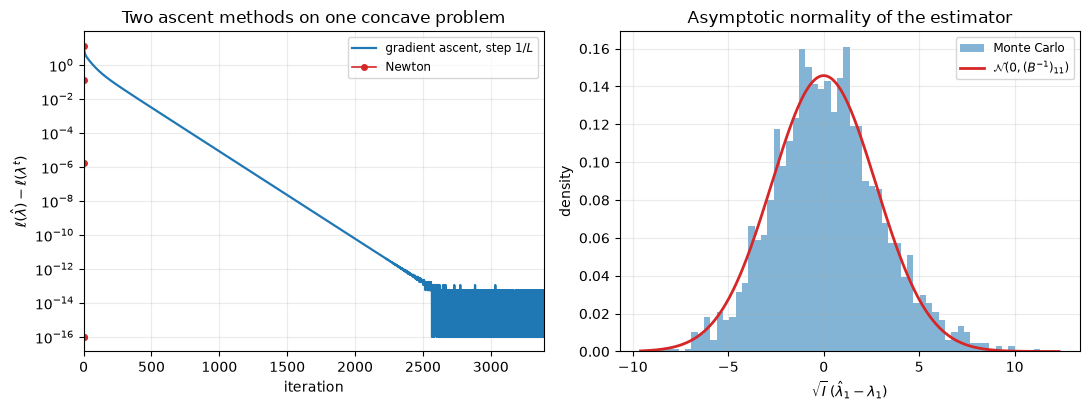

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# left: convergence of the two algorithms
gap_gd = np.array([ll1 - loglike(l, Phi_iy_k, pihat_iy, I, Y)
                   for l in path_gd[:min(len(path_gd), 4000)]])
gap_nr = np.array([ll1 - loglike(l, Phi_iy_k, pihat_iy, I, Y) for l in path_nr])
ax[0].semilogy(np.maximum(gap_gd, 1e-16), color='C0', lw=1.6,
               label=f'gradient ascent, step $1/L$')
ax[0].semilogy(np.maximum(gap_nr, 1e-16), 'o-', color='C3', ms=4, lw=1.2,
               label='Newton')
ax[0].set_xlabel('iteration'); ax[0].set_ylabel(r'$\ell(\hat\lambda)-\ell(\lambda^t)$')
ax[0].set_title('Two ascent methods on one concave problem')
ax[0].set_xlim(0, min(len(gap_gd), 4000)); ax[0].legend(fontsize=8.5)
ax[0].grid(alpha=.25, which='both')

# right: the CLT for lambda_1
k_show = 0
ax[1].hist(np.sqrt(I) * (lam_mc[:, k_show] - lam_nr[k_show]), bins=60, density=True,
           color='C0', alpha=.55, edgecolor='none', label='Monte Carlo')
xs = np.linspace(*ax[1].get_xlim(), 400)
sd = np.sqrt(np.linalg.inv(Bhat)[k_show, k_show])
ax[1].plot(xs, stats.norm.pdf(xs, 0, sd), color='C3', lw=2,
           label=r'$\mathcal{N}(0,(B^{-1})_{11})$')
ax[1].set_xlabel(r'$\sqrt{I}\,(\hat\lambda_1-\lambda_1)$'); ax[1].set_ylabel('density')
ax[1].set_title('Asymptotic normality of the estimator')
ax[1].legend(fontsize=8.5); ax[1].grid(alpha=.25)

plt.tight_layout(); plt.show()

*Left.* Both methods climb the same concave function to the same optimum. Newton's quadratic convergence flattens the gap to machine precision in a handful of steps; the fixed-step gradient method decays geometrically at a rate set by the condition number of $\hat B$. The gap between the two curves is the value of knowing the Hessian — and lecture 4 will meet a problem where the Hessian is unavailable because the objective is not differentiable.

*Right.* The sampling distribution of $\sqrt{I}(\hat\lambda_1-\lambda_1)$ against the $\mathcal{N}(0,B^{-1})$ density of theorem 3.4. At $I=210$ the normal approximation is already good, which is what licenses the intervals in the table above.

## Summing up

* **Estimation is a maximum-entropy problem.** The method-of-moments estimator maximizes $\hat\pi^\top\Phi\lambda - \sum_iG$, whose dual minimizes the entropy of choice subject to moment matching; $\lambda$ is the vector of multipliers on the moments. We verified equality of the two values and, by perturbing along the null space of the constraints, that the fitted $\pi$ really is the entropy minimizer.
* **The logit is the case where likelihood and moments coincide**, and where the objective is strictly concave — the Hessian's eigenvalues came out negative, and two very different ascent methods reached the same $\hat\lambda$.
* **Multinomial logistic regression is a Poisson regression with individual fixed effects**, and the fixed effect is the traveller's indirect utility $u_i = \log\sum_ye^{U_{iy}}$ — simultaneously the multiplier on "one choice per person". A 3-parameter and a 213-parameter problem returned the same three numbers.
* **The Poisson trick estimates but does not infer.** Its naive standard errors were visibly wrong against a Monte Carlo, because it treats the $IY$ rows as independent when the $Y$ rows of an individual are not. The Fisher matrix $\hat B$ has to be computed separately, and then the intervals are right.
* **The economics: the value of travel time rises with income.** Estimated from choices alone, with no stated-preference question and no wage data, and identified purely by the fact that richer travellers in the sample trade time against cost differently. That is the payoff of parametrizing $U$ rather than inverting shares — and lecture 4 asks when this estimator exists at all, and what to do when $K$ grows large relative to $I$.

## Exercises

Exercises 1 and 3 correspond to book exercises for chapter 3, whose code stubs are listings `3-07` and `3-08`.

**1. (Computation — the usual multinomial parametrization.)** The common form of multinomial logistic regression sets $U_{iy} = \sum_{l\in[L]}\Psi_{il}\theta_{ly}$, one coefficient vector per option, rather than the book's $U_{iy}=(\Phi\lambda)_{iy}$. Show that it is a special case by constructing the corresponding $\Phi$, and verify numerically on simulated data that your construction reproduces the coefficients that a standard routine returns — recalling that $\theta$ is identified only up to a common shift across options, so compare $\theta_{y\cdot}-\theta_{1\cdot}$.

**2. (Proof — the Hessian.)** Derive expression (3.14),
$D^2\ell(\lambda) = -\Phi^\top(\mathbf\Delta_\pi - \mathbf\Delta_\pi(\mathbf I_I\otimes\mathbf 1_{Y\times Y})\mathbf\Delta_\pi)\Phi$,
and show directly that it is negative semidefinite, with a null space you should characterize. What feature of $\Phi$ would make $\ell$ merely concave rather than strictly concave, and what would that mean for the identification of $\lambda$?

**3. (Computation — panel data with fixed effects.)** Listing `3-08` sets up a model with a time index $t$, states $x$, options $y$ and regressors $\phi_{txyk}$. Write down the log-likelihood for $\hat\mu_{txy}$, estimate $\lambda$, and show that the Poisson representation now carries a fixed effect per $(t,x)$ cell rather than per individual. What is that fixed effect the price of?

**4. (Computation — moments you did not match.)** Re-estimate the travel-mode model adding a fourth regressor of your choice, and report how the *unmatched* aggregate market shares move. Then add enough regressors that $K$ approaches $Y-1$ times the number of distinct individual types, and describe what happens to the fit and to the standard errors. This is the overfitting problem lecture 4 regularizes.

**5. (Economics — the value of time.)** Using the estimated $\hat\lambda$, compute the marginal rate of substitution between travel time and generalized cost, in the data's own units, for a traveller at the 25th, 50th and 75th percentile of income. Report a confidence interval for each using the delta method and $\hat B$. Then explain why this number is identified *only* through the income interaction, and what would be lost if the second regressor were dropped. Lecture 7 estimates the same object in a market where prices are endogenous, and finds that this estimate is biased; conjecture the sign.

---

### Run notes

`FAST_MODE = True` runs 2,000 Monte Carlo replications of the estimator; `False` runs 4,000. Every assertion holds in both modes. The notebook uses numpy, scipy, pandas and matplotlib only — the Poisson regression that the book's listing `3-02` delegates to scikit-learn is implemented here with `scipy.optimize`, so that the equivalence in theorem 3.3 is verified rather than assumed, and no additional dependency is introduced.

**Next:** lecture 4 completes chapter 3 — when does $\hat\lambda$ exist, what does the zero-cell problem do to it, how do L1 and L2 penalties change the estimator, and what happens in the small-noise limit where the logit becomes a linear program.